# Stage 06: Data Preprocessing - Completed Submission

This notebook uses the committed S&P 500 dirty-data fixture in `data/raw/`, imports the three required functions from `src/cleaning.py`, compares the data before and after cleaning, validates the result, and saves reproducible outputs to `data/processed/`.

Required functions demonstrated: `fill_missing_median()`, `drop_missing()`, and `normalize_data()`.

## Cleaning Plan and Decision Boundary

1. Coerce the date and formatted market fields to appropriate data types.
2. Drop only the row whose date cannot be parsed because it cannot be positioned chronologically.
3. Median-fill the missing `close` and `volume` values to demonstrate the required imputation method.
4. Add MinMax-normalized close and Z-score-normalized volume features.
5. Compare original and cleaned quality metrics, validate all invariants, and save stable outputs.

These transformations support coursework and later analysis; they are not investment advice or an automated trading rule.

In [1]:
import inspect
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "homework" / "homework06").exists()
)
HOMEWORK_DIR = REPO_ROOT / "homework" / "homework06"
load_dotenv(HOMEWORK_DIR / ".env")
RAW_DIR = HOMEWORK_DIR / os.environ.get("DATA_DIR_RAW", "data/raw")
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get("DATA_DIR_PROCESSED", "data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR))
from src.cleaning import drop_missing, fill_missing_median, normalize_data
from src.preprocess_utils import clean_market_prices, missingness_summary, validate_cleaned_prices

print("Homework directory:", HOMEWORK_DIR.resolve())
print("Required functions:", [drop_missing.__name__, fill_missing_median.__name__, normalize_data.__name__])

Homework directory: C:\Users\yifunger\Documents\Codex\2026-08-18\new-chat\work\bootcamp_Yifang_Qiu\homework\homework06
Required functions: ['drop_missing', 'fill_missing_median', 'normalize_data']


## Verify Modular Functions and Documentation

In [2]:
function_documentation = pd.DataFrame(
    {
        "function": [fill_missing_median.__name__, drop_missing.__name__, normalize_data.__name__],
        "module": [fn.__module__ for fn in [fill_missing_median, drop_missing, normalize_data]],
        "has_docstring": [bool(inspect.getdoc(fn)) for fn in [fill_missing_median, drop_missing, normalize_data]],
    }
)
assert function_documentation["has_docstring"].all()
assert set(function_documentation["module"]) == {"src.cleaning"}
function_documentation

,function,module,has_docstring
0,fill_missing_median,src.cleaning,True
1,drop_missing,src.cleaning,True
2,normalize_data,src.cleaning,True


## Load the Provided Raw Dataset

In [3]:
raw_path = RAW_DIR / "sp500_prices_dirty_fixture_20260820-050305.csv"
if not raw_path.exists():
    raise FileNotFoundError(f"Required raw fixture not found: {raw_path}")

raw_data = pd.read_csv(raw_path)
print("Raw shape:", raw_data.shape)
raw_data.head(10)

Raw shape: (20, 7)


,date,ticker,open,high,low,close,volume
0,2025-01-02,^gspc,5903.259766,5935.089844,5829.529785,"$5,868.55","3,621,680,000"
1,2025-01-03,^gspc,5891.069824,5949.339844,5888.660156,"$5,942.47","3,667,340,000"
2,2025-01-06,^gspc,5982.810059,6021.040039,5960.009766,"$5,975.38","4,940,120,000"
3,2025-01-07,^gspc,5993.259766,6000.680176,5890.680176,"$5,909.03","4,517,330,000"
4,2025-01-08,^gspc,5910.660156,5927.890137,5874.779785,NaN,"4,441,740,000"
5,2025-01-10,^gspc,5890.350098,5890.350098,5807.779785,"$5,827.04","4,751,930,000"
6,2025-01-13,^gspc,5782.020020,5838.609863,5773.310059,"$5,836.22","4,421,200,000"
7,2025-01-14,^gspc,5859.270020,5871.919922,5805.419922,"$5,842.91","4,142,280,000"
8,2025-01-15,^gspc,5905.209961,5960.609863,5905.209961,"$5,949.91","4,544,570,000"
9,2025-01-16,^gspc,5963.609863,5964.689941,5930.720215,"$5,937.34",NaN


## Inspect Original Missingness

The fixture contains deliberately introduced missing numeric values and one invalid date string. This is a controlled teaching example and does not establish the real-world missingness mechanism.

,missing_count,missing_rate
volume,1,0.05
close,1,0.05
date,0,0.00
open,0,0.00
ticker,0,0.00
low,0,0.00
high,0,0.00


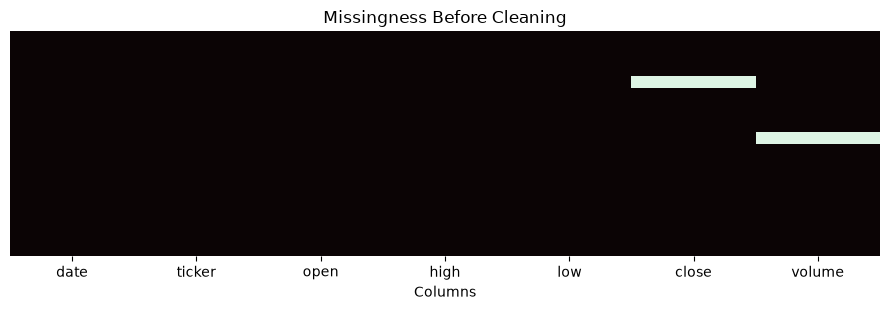

In [4]:
missing_before = missingness_summary(raw_data)
display(missing_before)

plt.figure(figsize=(9, 3.2))
sns.heatmap(raw_data.isna(), cbar=False, yticklabels=False, cmap="mako")
plt.title("Missingness Before Cleaning")
plt.xlabel("Columns")
plt.tight_layout()
missingness_plot_path = PROCESSED_DIR / "missingness_before_cleaning.png"
plt.savefig(missingness_plot_path, dpi=150, bbox_inches="tight")
plt.show()

## Correct Data Types Before Applying Missing-Value Rules

In [5]:
typed_data = raw_data.copy(deep=True)
typed_data["date"] = pd.to_datetime(typed_data["date"], errors="coerce")
typed_data["ticker"] = typed_data["ticker"].astype("string").str.strip().str.upper().astype("category")

price_columns = ["open", "high", "low", "close", "volume"]
for column in price_columns:
    cleaned_strings = (
        typed_data[column]
        .astype("string")
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    typed_data[column] = pd.to_numeric(cleaned_strings, errors="coerce")

print("Missing after type coercion:", typed_data.isna().sum().to_dict())
typed_data.dtypes.astype(str).to_frame("dtype")

Missing after type coercion:

 {'date': 1, 'ticker': 0, 'open': 0, 'high': 0, 'low': 0, 'close': 1, 'volume': 1}


,dtype
date,datetime64[us]
ticker,category
open,Float64
high,Float64
low,Float64
close,Float64
volume,Int64


## Demonstrate `drop_missing()`

Only rows with an invalid required date are removed. Numeric missing values remain for the imputation demonstration.

In [6]:
invalid_date_count = int(typed_data["date"].isna().sum())
after_drop = drop_missing(typed_data, subset=["date"])
after_drop = after_drop.sort_values("date").reset_index(drop=True)

print("Invalid date rows before:", invalid_date_count)
print("Rows before/after:", len(typed_data), len(after_drop))
assert len(typed_data) - len(after_drop) == invalid_date_count
assert after_drop["date"].notna().all()

Invalid date rows before: 1
Rows before/after: 20 19


## Demonstrate `fill_missing_median()`

Median imputation is applied only to `close` and `volume`. The original DataFrame remains unchanged, which makes the transformation auditable.

In [7]:
numeric_missing_before = after_drop[["close", "volume"]].isna().sum()
after_fill = fill_missing_median(after_drop, ["close", "volume"])
numeric_missing_after = after_fill[["close", "volume"]].isna().sum()

median_comparison = pd.DataFrame(
    {
        "missing_before": numeric_missing_before,
        "median_used": after_drop[["close", "volume"]].median(),
        "missing_after": numeric_missing_after,
    }
)
assert numeric_missing_before.sum() == 2
assert numeric_missing_after.sum() == 0
median_comparison

,missing_before,median_used,missing_after
close,1,5986.02,0
volume,1,4436995000.0,0


## Demonstrate `normalize_data()`

Close is scaled to [0, 1]. Volume is converted to a population Z-score. Constant columns would be mapped safely to 0.0 by the reusable function.

In [8]:
cleaned_data = normalize_data(after_fill, ["close"], method="minmax", suffix="_minmax")
cleaned_data = normalize_data(cleaned_data, ["volume"], method="zscore", suffix="_zscore")
cleaned_data["daily_return"] = cleaned_data["close"].pct_change(fill_method=None).fillna(0.0)

# Match the documented output order.
cleaned_data = cleaned_data[
    ["date", "ticker", "open", "high", "low", "close", "volume",
     "daily_return", "close_minmax", "volume_zscore"]
]

normalization_checks = {
    "close_min": float(cleaned_data["close_minmax"].min()),
    "close_max": float(cleaned_data["close_minmax"].max()),
    "volume_zscore_mean": float(cleaned_data["volume_zscore"].mean()),
    "volume_zscore_std": float(cleaned_data["volume_zscore"].std(ddof=0)),
}
assert abs(normalization_checks["close_min"]) < 1e-12
assert abs(normalization_checks["close_max"] - 1.0) < 1e-12
assert abs(normalization_checks["volume_zscore_mean"]) < 1e-12
assert abs(normalization_checks["volume_zscore_std"] - 1.0) < 1e-12
normalization_checks

{'close_min': 0.0,
 'close_max': 1.0,
 'volume_zscore_mean': 3.0385051200267443e-16,
 'volume_zscore_std': 1.0}

## Verify the Composed Market Pipeline

The market-specific wrapper imports and composes the same three required functions. Its output must exactly match the step-by-step demonstration.

In [9]:
pipeline_data, cleaning_decisions = clean_market_prices(raw_data)
pd.testing.assert_frame_equal(cleaned_data, pipeline_data)
print("Cleaning decisions:", cleaning_decisions)
print("Step-by-step output matches modular pipeline: True")

Cleaning decisions: {'invalid_dates_dropped': 1, 'median_values_filled': {'close': 1, 'volume': 1}, 'normalization': {'close': 'minmax', 'volume': 'zscore'}}
Step-by-step output matches modular pipeline: True


## Compare Original and Cleaned Data

In [10]:
comparison = pd.DataFrame(
    {
        "metric": [
            "rows", "columns", "total_missing_cells", "invalid_dates",
            "duplicate_rows", "numeric_columns"
        ],
        "original": [
            len(raw_data),
            raw_data.shape[1],
            int(raw_data.isna().sum().sum()),
            int(pd.to_datetime(raw_data["date"], errors="coerce").isna().sum()),
            int(raw_data.duplicated().sum()),
            int(raw_data.select_dtypes(include="number").shape[1]),
        ],
        "cleaned": [
            len(cleaned_data),
            cleaned_data.shape[1],
            int(cleaned_data.isna().sum().sum()),
            int(cleaned_data["date"].isna().sum()),
            int(cleaned_data.duplicated().sum()),
            int(cleaned_data.select_dtypes(include="number").shape[1]),
        ],
    }
)
display(comparison)

distribution_comparison = pd.concat(
    {
        "before_imputation": after_drop[["close", "volume"]].describe(),
        "after_imputation": cleaned_data[["close", "volume"]].describe(),
    },
    axis=1,
)
distribution_comparison

,metric,original,cleaned
0,rows,20,19
1,columns,7,10
2,total_missing_cells,2,0
3,invalid_dates,1,0
4,duplicate_rows,0,0
5,numeric_columns,3,8


before_imputation                   after_imputation                   
                  close            volume            close             volume
count              18.0              18.0             19.0               19.0
mean        5981.098889      4397490000.0      5981.357895  4399569210.526316
std           96.395351  354309441.042381        93.686245   344446138.832019
min             5827.04      3621680000.0          5827.04       3621680000.0
25%           5916.1075      4241447500.0         5923.185       4268645000.0
50%             5986.02      4436995000.0          5986.02       4436995000.0
75%            6063.085      4612107500.0          6058.47       4589595000.0
max             6118.71      4940120000.0          6118.71       4940120000.0

## Validate and Save the Cleaned Dataset

In [11]:
validation_results = validate_cleaned_prices(cleaned_data)
assert all(validation_results.values())

processed_csv_path = PROCESSED_DIR / "sp500_prices_cleaned.csv"
processed_parquet_path = PROCESSED_DIR / "sp500_prices_cleaned.parquet"
comparison_path = PROCESSED_DIR / "cleaning_comparison.csv"
metadata_path = PROCESSED_DIR / "cleaning_metadata.json"

cleaned_data.to_csv(processed_csv_path, index=False)
cleaned_data.to_parquet(processed_parquet_path, index=False)
comparison.to_csv(comparison_path, index=False)

assumptions = [
    "Missing values and the invalid date were deliberately introduced for this teaching fixture.",
    "An invalid date is dropped because the row cannot be placed chronologically.",
    "Median imputation is deterministic and robust to extremes but reduces variability.",
    "Scaling is descriptive here; production fitting must use training data only.",
]
metadata = {
    "source_file": str(raw_path.relative_to(REPO_ROOT)),
    "required_functions": ["fill_missing_median", "drop_missing", "normalize_data"],
    "cleaning_decisions": cleaning_decisions,
    "validation_results": validation_results,
    "assumptions": assumptions,
    "outputs": {
        "csv": str(processed_csv_path.relative_to(REPO_ROOT)),
        "parquet": str(processed_parquet_path.relative_to(REPO_ROOT)),
        "comparison": str(comparison_path.relative_to(REPO_ROOT)),
        "missingness_plot": str(missingness_plot_path.relative_to(REPO_ROOT)),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

reloaded_data = pd.read_parquet(processed_parquet_path)
# Parquet may reconstruct equivalent categorical labels with a different
# internal string dtype; values and all validation invariants must still match.
pd.testing.assert_frame_equal(
    cleaned_data,
    reloaded_data,
    check_dtype=False,
    check_categorical=False,
)
assert validate_cleaned_prices(reloaded_data) == validation_results

print("Validation:", validation_results)
print("Saved and reloaded:", processed_csv_path.name, processed_parquet_path.name)
print("Supporting outputs:", comparison_path.name, metadata_path.name, missingness_plot_path.name)

Validation: {'no_missing_values': True, 'date_is_datetime': True, 'close_is_numeric': True, 'positive_prices': True, 'nonnegative_volume': True, 'dates_sorted': True}
Saved and reloaded: sp500_prices_cleaned.csv sp500_prices_cleaned.parquet
Supporting outputs: cleaning_comparison.csv cleaning_metadata.json missingness_before_cleaning.png


## Assumptions, Tradeoffs, and Reflection

- **Missingness mechanism:** The gaps are intentionally injected, so this exercise cannot infer MCAR, MAR, or MNAR behavior in real market data.
- **Median filling:** It is robust and reproducible, but replacing a missing close with the global sample median can distort local time-series movement and reduce variance. Time interpolation may be preferable when its continuity assumption is defensible.
- **Row deletion:** Dropping the invalid-date row is necessary for chronological analysis, but systematic parsing failures would require source repair rather than silent deletion.
- **Normalization:** MinMax values are easy to interpret and Z-scores aid comparison, but both depend on the fitted sample. Future modeling must fit scaling parameters on training data only.
- **Observed impact:** The workflow removes one unusable row, resolves two missing numeric cells, adds three analysis features, and leaves no missing values in the validated output.

The selected rules are appropriate for this small teaching fixture. They are documented decisions, not universal defaults for production financial data.

## Completion Checklist

- [x] Required functions implemented in `src/cleaning.py` with docstrings.
- [x] All three functions imported and demonstrated.
- [x] Original and cleaned data compared.
- [x] Assumptions and tradeoffs documented.
- [x] Cleaned CSV and Parquet saved to `data/processed/`.
- [x] Saved Parquet reloaded and validated.
- [x] README contains the cleaning strategy.